In [169]:
import numpy as np

In [186]:
class Linear_Regression:
    def __init__(self, regularisation_l2=False, alpha=1.0):
        self.regularisation = regularisation_l2
        self.alpha = alpha

        self.coeff = None
        self.intercept = 0.0

    def fit(self, X_, y_):

        X_ = np.asarray(X_, dtype=np.float64)
        y_ = np.asarray(y_, dtype=np.float64)

        # Make them Zero-centered to calculate intercept
        X_mean = np.mean(X_, axis = 0)
        y_mean = np.mean(y_, axis = 0)
        
        X = X_ - X_mean
        y = y_ - y_mean

        if y.ndim == 1:
            y = y.reshape(-1, 1)

        # theta = (X.T @ X)-1 @ X.T @ y
        # With l2: theta = (X.T @ X + I * alpha)-1 @ X.T @ y

        XtX = X.T @ X

        if self.regularisation:
            n_fet = XtX.shape[0]
            I = np.eye(n_fet)

            XtX = XtX + self.alpha * I

        inv_mat = np.linalg.pinv(XtX)

        theta = inv_mat @ X.T @ y

        self.coeff = theta.flatten()

        # b = y_mean - X_mean @ theta
        self.intercept = (y_mean - X_mean @ self.coeff)

        return self

    def predict(self ,X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.coeff + self.intercept
      

In [187]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Generates 4000 samples with 10 features, but only 12 features actually matter
X, y = make_regression(n_samples=4000, n_features=12, n_informative=4, noise=5.0, random_state=42)

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)

In [188]:
model = Linear_Regression()

model.fit(x_train,y_train)
y_pred = model.predict(x_test)

from sklearn.metrics import r2_score
print('R2_score: ',r2_score(y_pred,y_test))

R2_score:  0.9958441294187159


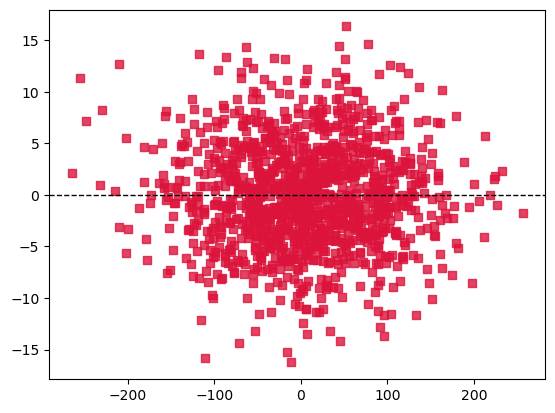

In [189]:
import matplotlib.pyplot as plt

res = y_test - y_pred

# Plot validation residuals
plt.scatter(y_pred,res, color='crimson', alpha=0.8, label='Validation Data', marker='s')

# Add the ideal horizontal baseline at 0 error
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.show()

In [190]:
model.coeff

array([-1.52108662e-01,  1.64488920e-02,  1.25702171e+01, -4.43429022e-02,
       -8.06665021e-03,  2.05736752e-02,  1.68568478e-01,  7.53662924e+01,
        5.32483732e-02,  1.94374663e+01, -8.08625388e-02,  1.94342970e+01])

In [191]:
model.intercept

np.float64(0.05145925168379861)